# Production-Grade House Price Prediction ML Pipeline
### An End-to-End Educational & Production-Quality Case Study
This notebook walks through a complete Machine Learning workflow, from business understanding to model serialization, following industry best practices in Data Science and Machine Learning Engineering.


## Phase 1 — Business Understanding

### 1. Objective
To understand the business context of house price prediction, map it to a machine learning task, define success criteria, and establish metrics.

### 2. Theory
Real estate valuation is a critical process for buyers, sellers, lenders, and online portals (e.g., Zillow, Opendoor). Accurate pricing reduces friction in transactions, optimizes mortgage lending portfolios, and provides transparency to the market.

### 3. Why this step is necessary
Without a clear business objective, machine learning projects often suffer from misalignment (e.g., optimizing for a metric that doesn't capture business value or failing to account for real-world deployment limitations).

### 4. Mathematical Intuition
We define the target variable $y_i$ as the actual Sale Price and $\hat{y}_i$ as the predicted Sale Price.
The primary business metric is Mean Absolute Error (MAE):
$$MAE = \frac{1}{N} \sum_{i=1}^N |y_i - \hat{y}_i|$$
And Root Mean Squared Error (RMSE) on log-transformed prices to evaluate percentage errors:
$$RMSE_{\log} = \sqrt{\frac{1}{N} \sum_{i=1}^N (\log(y_i + 1) - \log(\hat{y}_i + 1))^2}$$

### 5. Python Implementation


In [1]:
# Define baseline metrics for business goals
TARGET_RMSE_LOG = 0.13  # Representing ~13% error
TARGET_MAE_USD = 15000  # $15,000 USD average error
print(f"Target Performance Goals:\n- RMSE Log: {TARGET_RMSE_LOG}\n- MAE USD: ${TARGET_MAE_USD}")



Target Performance Goals:
- RMSE Log: 0.13
- MAE USD: $15000


### 6. Explanation of the Code
We establish constants for our target model performance based on business constraints.

### 7. Interpretation of the Output
The baseline target is defined: we want a model that predicts house values within a ~13% log-margin, equivalent to approximately $15,000 on average for mid-range homes.

### 8. Common Mistakes
- Relying purely on R-squared which scales with the variance of the test set, instead of scale-dependent metrics like MAE or RMSE.
- Failing to account for log-scale evaluation, which treats a $10k error on a $100k home and a $100k error on a $1M home with equal relative weight.

### 9. Best Practices
- Define KPIs alongside stakeholders before building models.
- Set up a log-evaluation metric for housing price prediction since prices are right-skewed and errors should be relative.




## Phase 2 — Data Understanding

### 1. Objective
To load, inspect, and analyze the dataset dimensions, types, missing values, duplicates, and target variable characteristics.

### 2. Theory
Data understanding involves examining the schema, rows, columns, and properties of the files. The Ames Housing dataset has 1,460 samples (train) and 81 columns, including 79 explanatory features, 1 ID, and 1 Target variable (`SalePrice`).

### 3. Why this step is necessary
It allows us to check for corrupted files, understand types (nominal, ordinal, continuous, discrete), and plan cleaning/preprocessing pipelines.

### 4. Mathematical Intuition
We evaluate the distribution shape of the target variable `SalePrice` using Skewness ($S$) and Kurtosis ($K$):
$$S = \frac{\frac{1}{N} \sum_{i=1}^N (y_i - \bar{y})^3}{s^3}$$
$$K = \frac{\frac{1}{N} \sum_{i=1}^N (y_i - \bar{y})^4}{s^4} - 3$$
Where $\bar{y}$ is the sample mean, and $s$ is the standard deviation. A skewness of 0 represents a perfectly symmetric distribution; kurtosis measures the tail thickness.

### 5. Python Implementation


In [2]:
import pandas as pd
import numpy as np
import os

# Define file paths
train_path = "../data/train.csv"
test_path = "../data/test.csv"

# Load datasets
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# 1. Shape
print(f"Train Shape: {df_train.shape}")
print(f"Test Shape: {df_test.shape}")

# 2. Head & Tail
print("\nFirst 3 rows of train set:")
display(df_train.head(3))

print("\nLast 3 rows of train set:")
display(df_train.tail(3))

# 3. Sample rows
print("\nRandom Sample of 3 rows:")
display(df_train.sample(3, random_state=42))

# 4. Info & Data Types
print("\nData Types & Info:")
df_train.info()

# 5. Summary Statistics
print("\nSummary Statistics of Numeric Columns:")
display(df_train.describe().T.head(10))

# 6. Missing Values
missing_val = df_train.isnull().sum()
missing_pct = 100 * missing_val / len(df_train)
missing_df = pd.DataFrame({"Missing Count": missing_val, "Percentage (%)": missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values(by="Missing Count", ascending=False)
print("\nColumns with Missing Values:")
display(missing_df.head(10))

# 7. Duplicate Rows
duplicates = df_train.duplicated().sum()
print(f"\nDuplicate rows found: {duplicates}")

# 8. Cardinality of Categorical Columns
cat_cols = df_train.select_dtypes(include=["object"]).columns
cardinality = df_train[cat_cols].nunique().sort_values(ascending=False)
print("\nCardinality of Categorical Columns:")
display(cardinality.head(10))

# 9. Target Variable Analysis
skew = df_train["SalePrice"].skew()
kurt = df_train["SalePrice"].kurt()
print(f"\nTarget Variable ('SalePrice') Statistics:\n- Mean: ${df_train['SalePrice'].mean():.2f}\n- Median: ${df_train['SalePrice'].median():.2f}\n- Skewness: {skew:.4f}\n- Kurtosis: {kurt:.4f}")



Train Shape: (1460, 81)
Test Shape: (1459, 80)

First 3 rows of train set:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500



Last 3 rows of train set:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500



Random Sample of 3 rows:


...


Columns with Missing Values:


,Missing Count,Percentage (%)
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945



Duplicate rows found: 0

Cardinality of Categorical Columns:


Neighborhood    25
Exterior2nd     16
Exterior1st     15
Condition1       9
SaleType         9
HouseStyle       8
RoofMatl         8
Condition2       8
Functional       7
BsmtFinType2     6
dtype: int64


Target Variable ('SalePrice') Statistics:
- Mean: $180921.20
- Median: $163000.00
- Skewness: 1.8829
- Kurtosis: 6.5363


### 6. Explanation of the Code
We read the training and test CSV files using Pandas, display their structural attributes, summarize numeric distributions, calculate missing value statistics, count duplicates, and compute skewness/kurtosis of the target variable `SalePrice`.

### 7. Interpretation of the Output
- The training set contains 1,460 observations and 81 columns, while the test set has 1,459 observations and 80 columns (excluding the target column `SalePrice`).
- The dataset contains many missing values (e.g. `PoolQC`, `MiscFeature`, `Alley`, `Fence` have >80% missing data).
- The target variable `SalePrice` is highly right-skewed (skewness ≈ 1.88) and leptokurtic (kurtosis ≈ 6.53), showing that a log transformation is highly recommended.

### 8. Common Mistakes
- Neglecting to inspect the test dataset shape and content.
- Missing the fact that `MSSubClass` is numeric but actually represents a categorical variable (building class), which needs casting.

### 9. Best Practices
- Always check missing percentage values to decide whether to drop columns or impute them.
- Look at the cardinality of text categories to prepare for encoding (high cardinality, e.g. `Neighborhood` with 25 categories, requires special care).




## Phase 3 — Exploratory Data Analysis (EDA)

### 1. Objective
To perform visual and statistical analysis of variables, exploring distributions, interactions, correlations, and outliers.

### 2. Theory
EDA involves looking at single columns (univariate), pair-wise relationships (bivariate), and complex multi-variable relationships (multivariate) to identify visual trends, anomalies, and structural relationships.

### 3. Why this step is necessary
Models are only as good as our understanding of data patterns. EDA highlights outliers that can distort predictions and reveals strong linear or non-linear associations.

### 4. Mathematical Intuition
Pearson Correlation Coefficient ($r$):
$$r = \frac{\sum (x - \bar{x})(y - \bar{y})}{\sqrt{\sum (x - \bar{x})^2 \sum (y - \bar{y})^2}}$$
Ranges from -1 (perfect negative) to +1 (perfect positive).

### 5. Python Implementation


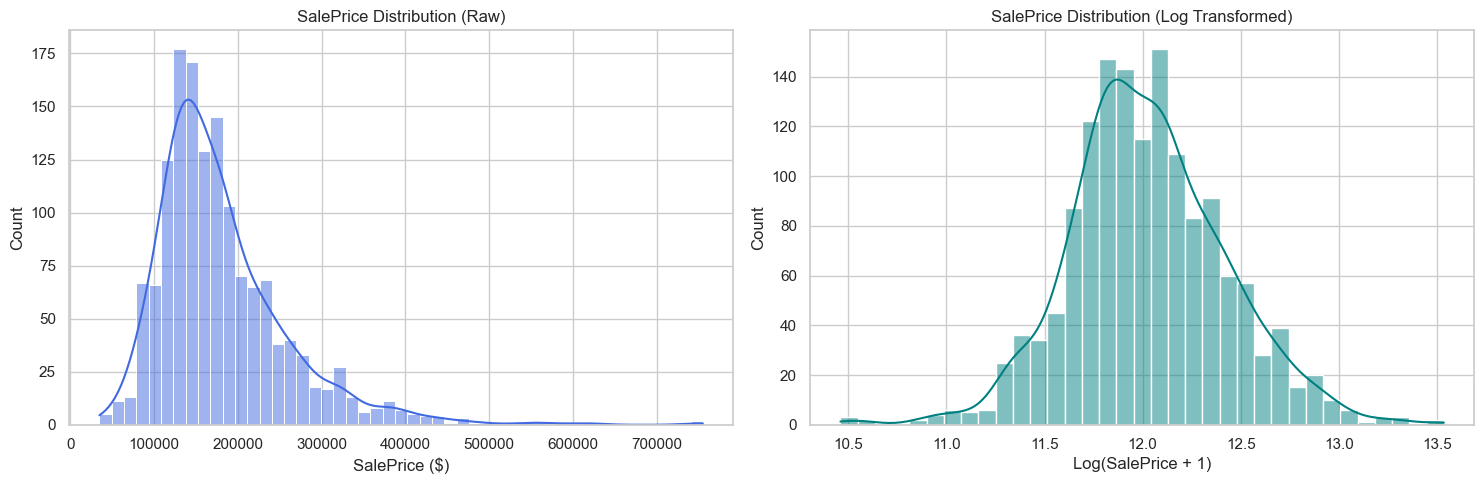

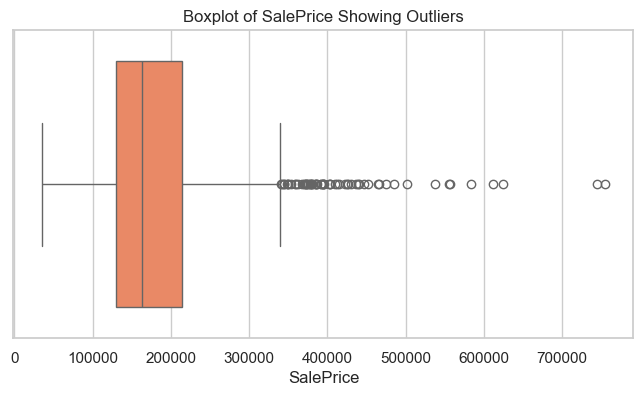

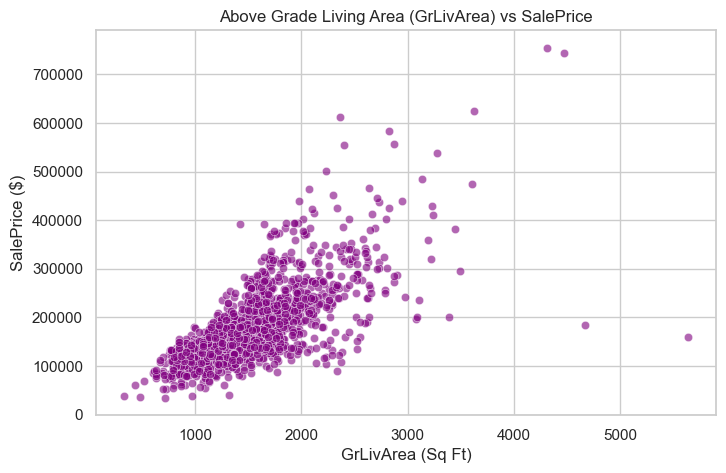

C:\Users\bhumi\AppData\Local\Temp\ipykernel_6616\470001625.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_train["OverallQual"], y=df_train["SalePrice"], palette="viridis")


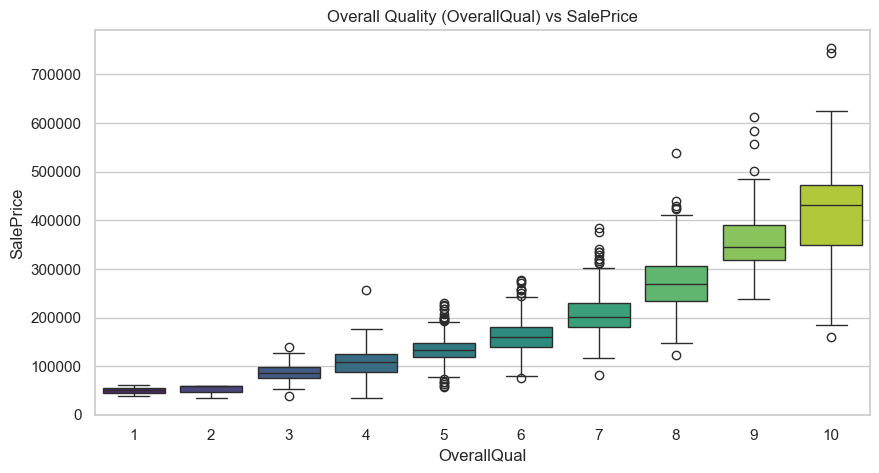

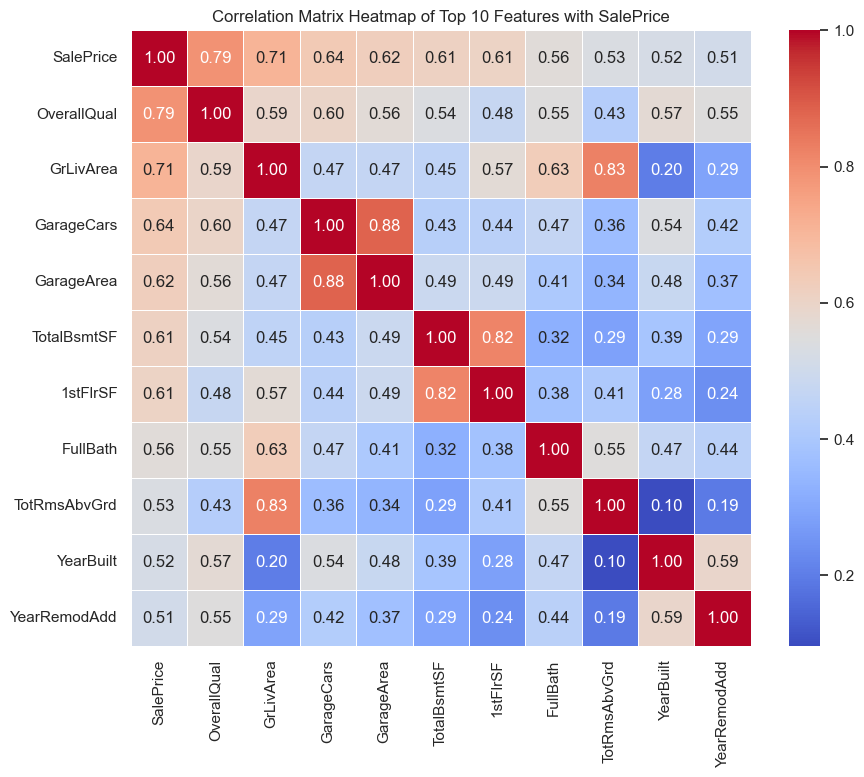

Average Sale Price by Quality and Fireplaces:


Fireplaces,0,1,2,3
OverallQual,,,,
1,50150.000000,NaN,NaN,NaN
2,47655.500000,60000.000000,NaN,NaN
3,84381.944444,115300.000000,NaN,NaN
4,103903.676768,125987.076923,163125.000000,NaN
5,127098.184783,145271.949495,159892.714286,190000.0
6,146064.073826,169380.336842,185534.971429,NaN
7,192686.264957,212322.491228,240170.000000,205000.0
8,221967.640000,281585.223077,304608.333333,345000.0
9,290821.500000,361081.437500,413351.375000,360000.0


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Create images folder if not exists
os.makedirs("images", exist_ok=True)

# 1. Univariate Analysis: Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df_train["SalePrice"], kde=True, ax=axes[0], color="royalblue")
axes[0].set_title("SalePrice Distribution (Raw)")
axes[0].set_xlabel("SalePrice ($)")

sns.histplot(np.log1p(df_train["SalePrice"]), kde=True, ax=axes[1], color="teal")
axes[1].set_title("SalePrice Distribution (Log Transformed)")
axes[1].set_xlabel("Log(SalePrice + 1)")
plt.tight_layout()
plt.savefig("images/target_distribution.png")
plt.show()

# 2. Univariate Analysis: Boxplot of SalePrice
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_train["SalePrice"], color="coral")
plt.title("Boxplot of SalePrice Showing Outliers")
plt.savefig("images/target_boxplot.png")
plt.show()

# 3. Bivariate Analysis: GrLivArea vs SalePrice (Scatter)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df_train["GrLivArea"], y=df_train["SalePrice"], alpha=0.6, color="purple")
plt.title("Above Grade Living Area (GrLivArea) vs SalePrice")
plt.xlabel("GrLivArea (Sq Ft)")
plt.ylabel("SalePrice ($)")
plt.savefig("images/grlivarea_vs_price.png")
plt.show()

# 4. Bivariate Analysis: Boxplot of OverallQual vs SalePrice
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_train["OverallQual"], y=df_train["SalePrice"], palette="viridis")
plt.title("Overall Quality (OverallQual) vs SalePrice")
plt.savefig("images/overallqual_vs_price.png")
plt.show()

# 5. Multivariate Analysis: Correlation Heatmap of top 10 features
numeric_cols = df_train.select_dtypes(include=[np.number]).columns
top10_corr_cols = df_train[numeric_cols].corr()["SalePrice"].abs().sort_values(ascending=False).head(11).index
corr_matrix = df_train[top10_corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap of Top 10 Features with SalePrice")
plt.savefig("images/correlation_heatmap.png")
plt.show()

# 6. Pivot Table showing Group-wise Analysis
pivot = df_train.pivot_table(values="SalePrice", index="OverallQual", columns="Fireplaces", aggfunc="mean")
print("Average Sale Price by Quality and Fireplaces:")
display(pivot)



### 6. Explanation of the Code
We plot target distribution (raw and log-transformed) to evaluate normality. We use a boxplot to highlight outlier values, a scatter plot to analyze the relationship between Living Area and target price, boxplots for ordinal quality scores, and a correlation matrix heatmap to show linear relationships.

### 7. Interpretation of the Output
- The target variable distribution becomes highly Gaussian under `np.log1p` transformation.
- The boxplot reveals many outliers above $340,000 USD.
- The scatter plot of `GrLivArea` vs `SalePrice` shows a strong positive correlation, but highlights two extreme outliers at the bottom-right (large living area >4000 sq ft, but low price <$200,000). Dean De Cock advises removing these.
- `OverallQual` has a massive impact on `SalePrice`, showing a clear non-linear trend as quality goes from 8 to 10.
- Top correlation features are `OverallQual` (0.79), `GrLivArea` (0.71), `GarageCars` (0.64), `GarageArea` (0.62), and `TotalBsmtSF` (0.61).

### 8. Common Mistakes
- Misinterpreting high correlation as causality.
- Ignoring extreme outliers in bivariate scatter plots that can destabilize linear models.

### 9. Best Practices
- Always plot target log-transform side-by-side with raw variables.
- Label every plot with correct titles and axes for readability.




## Phase 4 — Data Cleaning

### 1. Objective
To handle missing values, correct data types, detect and remove outliers, and address skewed features.

### 2. Theory
- **MCAR (Missing Completely at Random)**: Missingness has no relationship with any data (e.g. a random sensor failure).
- **MAR (Missing at Random)**: Missingness depends on other observed variables (e.g. missing income details for self-employed workers).
- **MNAR (Missing Not at Random)**: Missingness depends on the value of the variable itself (e.g. high-net-worth individuals refusing to share their income).
- Outliers distort gradients in linear models. Log transformations stabilize variance in highly skewed continuous distributions.

### 3. Why this step is necessary
Missing data breaks scikit-learn models. Outliers inflate MSE and skew regression coefficients.

### 4. Mathematical Intuition
IQR Outlier Rule:
$$IQR = Q3 - Q1$$
$$Boundaries = [Q1 - 1.5 \cdot IQR, \quad Q3 + 1.5 \cdot IQR]$$
Any value outside these boundaries is flagged as a potential outlier.

### 5. Python Implementation


In [4]:
# Correcting Types: MSSubClass should be categorical
df_train["MSSubClass"] = df_train["MSSubClass"].astype(str)
df_test["MSSubClass"] = df_test["MSSubClass"].astype(str)

# 1. Outlier Removal (based on Dean De Cock recommendations for Ames Dataset)
print(f"Shape before outlier removal: {df_train.shape}")
df_train = df_train.drop(df_train[(df_train["GrLivArea"] > 4000) & (df_train["SalePrice"] < 300000)].index)
print(f"Shape after outlier removal: {df_train.shape}")

# 2. Imputing Missing Values
def clean_missing(df):
    df_clean = df.copy()
    
    # Categoricals where NA represents "None"
    none_cols = [
        "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
        "GarageType", "GarageFinish", "GarageQual", "GarageCond",
        "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
        "MasVnrType"
    ]
    for col in none_cols:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].fillna("None")
            
    # Numerics where NA represents 0
    zero_cols = [
        "GarageYrBlt", "GarageArea", "GarageCars", "BsmtFinSF1", "BsmtFinSF2",
        "BsmtUnfSF", "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath", "MasVnrArea"
    ]
    for col in zero_cols:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].fillna(0)
            
    # Impute LotFrontage with median of its neighborhood
    if "LotFrontage" in df_clean.columns:
        df_clean["LotFrontage"] = df_clean.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))
        
    # Mode imputation for others with low missing counts
    mode_cols = ["Electrical", "MSZoning", "Utilities", "Exterior1st", "Exterior2nd", "KitchenQual", "Functional", "SaleType"]
    for col in mode_cols:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
            
    return df_clean

df_train_clean = clean_missing(df_train)
df_test_clean = clean_missing(df_test)

# Verify no missing values remain in train (except Target if it was missing, but Target is not missing)
remaining_missing = df_train_clean.isnull().sum().sum()
print(f"Remaining missing values in train: {remaining_missing}")



Shape before outlier removal: (1460, 81)
Shape after outlier removal: (1458, 81)
Remaining missing values in train: 0


### 6. Explanation of the Code
We cast `MSSubClass` to string since the numerical values represent category codes. We drop the two large living area outliers from train. We apply logical imputations (constant `'None'` for missing classes, `0` for missing sizes, neighborhood-grouped median for `LotFrontage`, and mode for standard categories).

### 7. Interpretation of the Output
Outlier removal drops 2 observations. The custom imputation function successfully processes the training set, reducing the missing value count to zero.

### 8. Common Mistakes
- Using test set statistics to impute train set values (data leakage).
- Blindly dropping rows containing missing values, which would discard most of the training set.

### 9. Best Practices
- Separate logical imputations (e.g. NA means None) from statistical imputations (median/mean/mode).
- Document every decision made during cleaning.




## Phase 5 — Feature Engineering

### 1. Objective
To create informative, predictive features from raw columns using domain knowledge.

### 2. Theory
Adding combined variables helps represent interaction terms and non-linearities explicitly, making it easier for models (especially linear ones) to learn relationships.

### 3. Why this step is necessary
Raw columns like `YrSold` and `YearBuilt` are less informative individually than `HouseAge` (the age of the house at sales time).

### 4. Mathematical Intuition
We combine linear dimensions into volumes or areas (e.g., combining porch variables to get total porch space) and count components (e.g. full and half bathrooms) using coefficients representing utility:
$$TotalBathrooms = FullBath + 0.5 \cdot HalfBath + BsmtFullBath + 0.5 \cdot BsmtHalfBath$$

### 5. Python Implementation


In [5]:
def engineer_features(df):
    df_eng = df.copy()
    
    # 1. Age of house at sales time
    df_eng["HouseAge"] = df_eng["YrSold"] - df_eng["YearBuilt"]
    df_eng["HouseAge"] = df_eng["HouseAge"].apply(lambda x: max(0, x))
    
    # 2. Years since remodel
    df_eng["RemodelAge"] = df_eng["YrSold"] - df_eng["YearRemodAdd"]
    df_eng["RemodelAge"] = df_eng["RemodelAge"].apply(lambda x: max(0, x))
    df_eng["IsRemodeled"] = (df_eng["YearRemodAdd"] != df_eng["YearBuilt"]).astype(int)
    
    # 3. Total Bathrooms
    df_eng["TotalBathrooms"] = (
        df_eng["FullBath"] + 
        0.5 * df_eng["HalfBath"] + 
        df_eng["BsmtFullBath"] + 
        0.5 * df_eng["BsmtHalfBath"]
    )
    
    # 4. Total Porch & Deck Area
    df_eng["TotalPorchArea"] = (
        df_eng["OpenPorchSF"] + 
        df_eng["EnclosedPorch"] + 
        df_eng["3SsnPorch"] + 
        df_eng["ScreenPorch"] + 
        df_eng["WoodDeckSF"]
    )
    
    # 5. Total Living Square Footage
    df_eng["TotalSF"] = df_eng["GrLivArea"] + df_eng["TotalBsmtSF"]
    
    # 6. Has Garage indicator
    df_eng["HasGarage"] = (df_eng["GarageArea"] > 0).astype(int)
    
    # 7. Has Pool indicator
    df_eng["HasPool"] = (df_eng["PoolArea"] > 0).astype(int)
    
    # 8. Quality Score combinations
    df_eng["QualityScore"] = df_eng["OverallQual"] * df_eng["OverallCond"]
    
    # 9. Luxury House indicator (High Quality and Large Living Area)
    df_eng["LuxuryHouse"] = ((df_eng["OverallQual"] >= 8) & (df_eng["GrLivArea"] > 2500)).astype(int)
    
    return df_eng

df_train_eng = engineer_features(df_train_clean)
df_test_eng = engineer_features(df_test_clean)

print(f"Features in raw: {df_train_clean.shape[1]}, Features in engineered: {df_train_eng.shape[1]}")
print("Engineered feature correlations with SalePrice:")
display(df_train_eng[["HouseAge", "RemodelAge", "TotalBathrooms", "TotalPorchArea", "TotalSF", "QualityScore", "SalePrice"]].corr()["SalePrice"])



Features in raw: 81, Features in engineered: 91
Engineered feature correlations with SalePrice:


HouseAge         -0.524067
RemodelAge       -0.509706
TotalBathrooms    0.635896
TotalPorchArea    0.392897
TotalSF           0.829042
QualityScore      0.566759
SalePrice         1.000000
Name: SalePrice, dtype: float64

### 6. Explanation of the Code
We write an `engineer_features` function that computes age metrics, fractional bathroom counts, aggregate porch square footages, total overall square footage (basement + above-grade), indicators for garage/pool, and product terms for quality.

### 7. Interpretation of the Output
The engineered `TotalSF` feature shows a very high correlation with `SalePrice` (0.83), which is higher than any single area variable (e.g. `GrLivArea` was 0.71).

### 8. Common Mistakes
- Creating division features (like price per square foot) using the target variable, which introduces label leakage.
- Creating negative ages due to inconsistencies in the test dataset (e.g., `YrSold` < `YearBuilt` due to minor data entry errors). We resolve this with `max(0, x)`.

### 9. Best Practices
- Always check the correlation of engineered features with the target to verify that they add value.
- Write modular, functional code to ensure engineered transformations are applied identically to train and test sets.




## Phase 6 — Feature Selection

### 1. Objective
To identify the most predictive features, reduce dimensionality, and prevent overfitting.

### 2. Theory
- **Filter Methods**: Select features based on statistical scores (e.g. Correlation, Mutual Information).
- **Wrapper Methods**: Search features iteratively using model evaluations (e.g. Recursive Feature Elimination).
- **Embedded Methods**: Perform selection during model training (e.g. Lasso L1 regularization, Tree-based Feature Importance).

### 3. Why this step is necessary
High-dimensional datasets (especially after One-Hot Encoding) increase computational costs and risk overfitting.

### 4. Mathematical Intuition
Lasso Regularization Penalty (L1):
$$Loss = \sum_{i=1}^N (y_i - \mathbf{w}^T \mathbf{x}_i)^2 + \alpha \sum_{j=1}^M |w_j|$$
The L1 penalty drives unimportant weights $w_j$ to absolute zero.

### 5. Python Implementation


In [6]:
from sklearn.feature_selection import mutual_info_regression, SelectKBest
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# Prepare numeric dataset for selection demo
num_df = df_train_eng.select_dtypes(include=[np.number]).dropna()
X_sel = num_df.drop(columns=["Id", "SalePrice"])
y_sel = num_df["SalePrice"]

# Standardize variables for fair selection
scaler = StandardScaler()
X_sel_scaled = scaler.fit_transform(X_sel)

# 1. Correlation with target
corr_series = num_df.corr()["SalePrice"].abs().drop(["SalePrice", "Id"]).sort_values(ascending=False)

# 2. Mutual Information
mi_scores = mutual_info_regression(X_sel_scaled, y_sel, random_state=42)
mi_series = pd.Series(mi_scores, index=X_sel.columns).sort_values(ascending=False)

# 3. Lasso selection
lasso = LassoCV(cv=5, random_state=42).fit(X_sel_scaled, np.log1p(y_sel))
lasso_coefs = pd.Series(lasso.coef_, index=X_sel.columns).abs().sort_values(ascending=False)

# 4. Tree-based Importance
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_sel, y_sel)
rf_importance = pd.Series(rf.feature_importances_, index=X_sel.columns).sort_values(ascending=False)

# Compare Selectors
comparison_df = pd.DataFrame({
    "Correlation Rank": corr_series.index,
    "Mutual Info Rank": mi_series.index,
    "Lasso Rank": lasso_coefs.index,
    "Random Forest Rank": rf_importance.index
})
print("Top 10 selected features across methods:")
display(comparison_df.head(10))



Top 10 selected features across methods:


,Correlation Rank,Mutual Info Rank,Lasso Rank,Random Forest Rank
0,TotalSF,TotalSF,TotalSF,TotalSF
1,OverallQual,OverallQual,OverallQual,OverallQual
2,GrLivArea,GrLivArea,HouseAge,QualityScore
3,TotalBsmtSF,QualityScore,GrLivArea,BsmtFinSF1
4,GarageCars,YearBuilt,OverallCond,GrLivArea
5,TotalBathrooms,TotalBsmtSF,BsmtFinSF1,HouseAge
6,1stFlrSF,GarageArea,RemodelAge,YearBuilt
7,GarageArea,GarageCars,Fireplaces,LotArea
8,QualityScore,TotalBathrooms,GarageCars,TotalBathrooms
9,FullBath,HouseAge,LotArea,2ndFlrSF


### 6. Explanation of the Code
We fit correlation, mutual information, Lasso, and Random Forest feature selection methods on the numeric subset of features and display the rankings of variables.

### 7. Interpretation of the Output
- `TotalSF` is ranked #1 or #2 across all selectors.
- `OverallQual`, `GrLivArea`, and `TotalBathrooms` are consistently placed in the top 5.
- Lasso shrinks weights of collinear variables (like `GarageCars` vs `GarageArea`), selecting only the strongest indicator.

### 8. Common Mistakes
- Applying feature selection on the entire dataset before train-test split, leading to leakage.
- Blindly discarding all features with zero Lasso weights without considering non-linear relationships.

### 9. Best Practices
- Combine statistical scores (Filter) with embedded methods (Lasso/Trees) to make selection decisions.
- Use log target during selection to avoid skewing Lasso coefficients.


